In [1]:
!pip install pandas matplotlib seaborn

In [2]:
from google.colab import files

uploaded = files.upload()

Saving sales_data.csv.csv to sales_data.csv.csv


Dataset Shape:
(9994, 21)

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Cate

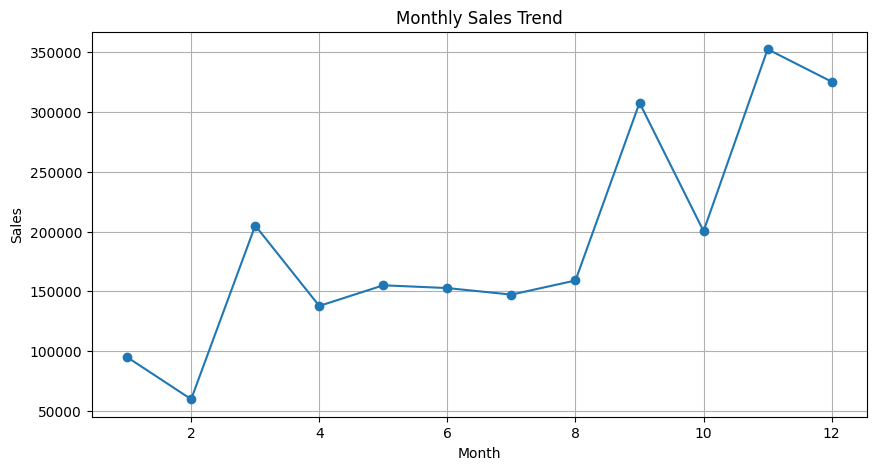

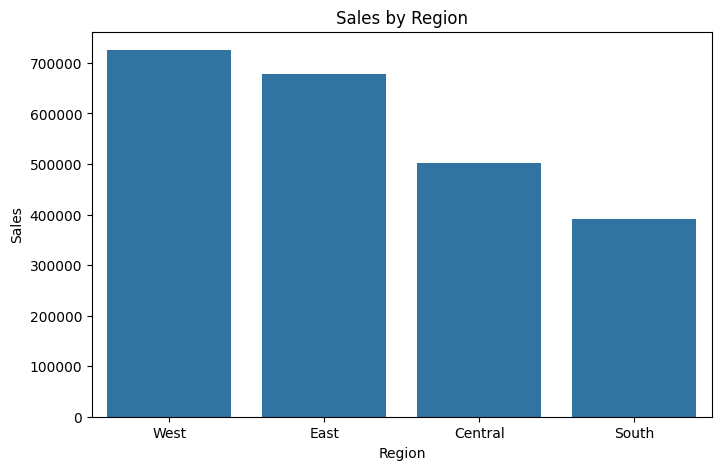

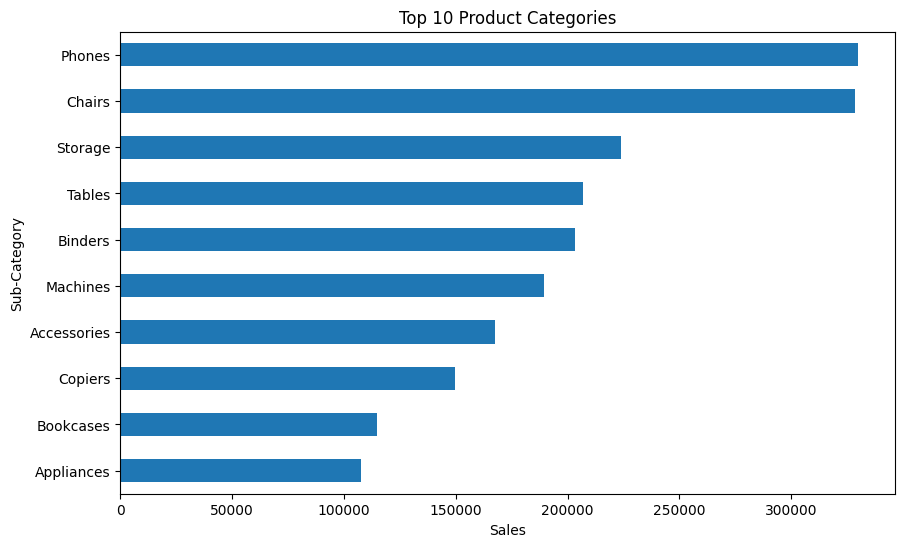


Analysis Completed Successfully!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("sales_data.csv.csv", encoding="latin1")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# Total Sales and Profit
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("\nTotal Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))

# Top 10 Product Categories
top_products = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Sub-Categories by Sales:")
print(top_products)

# Region-wise Sales
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nRegion-wise Sales:")
print(region_sales)

# Monthly Sales Trend
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.month)["Sales"]
    .sum()
)

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# Sales by Region
plt.figure(figsize=(8,5))
sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# Top Product Categories
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Product Categories")
plt.xlabel("Sales")
plt.show()

print("\nAnalysis Completed Successfully!")